In [6]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

In [7]:
import pandas as pd
import numpy as np
import os

from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [8]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [11]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/Lid_Driven_domain", meta = "Lid_Driven")
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse").to(device)
# use path = `stabilityai/sd-vae-ft-mse` for pulling weights from the internet

In [14]:
# pick one actual training example
images, numbers, mask = next(iter(dataloader))
true_number = numbers[0].item()      # already normalized, matches training distribution

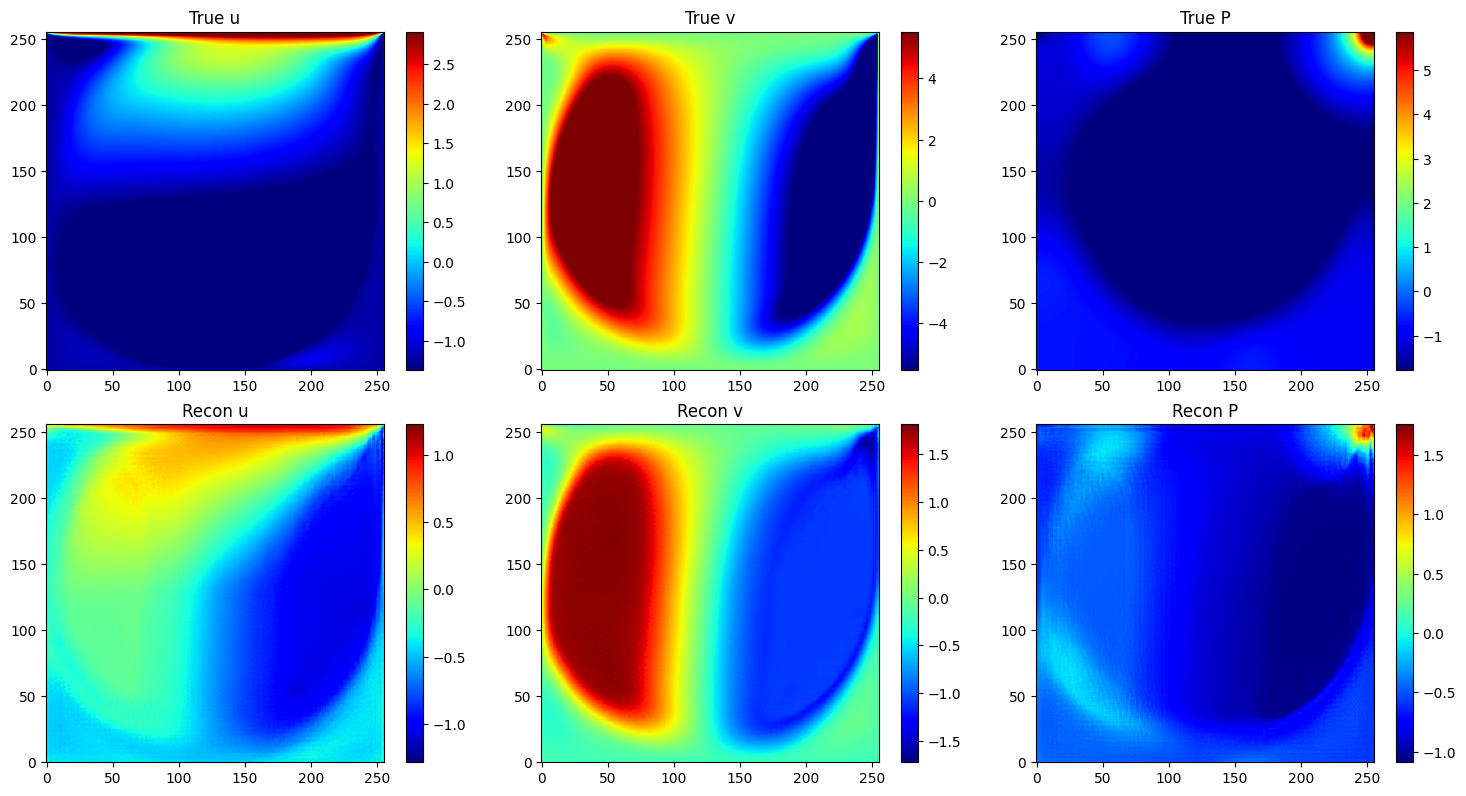

In [29]:
with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    recon = vae.decode(mu)  

idx = 0
true_np  = images[idx].detach().cpu().numpy()   
recon_np = recon[idx].detach().cpu().numpy()    

channel_names = ["u", "v", "P"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, name in enumerate(channel_names):
    vmin_true = true_np[i].min()
    vmax_true = true_np[i].max()

    vmin_recon = recon_np[i].min()
    vmax_recon = recon_np[i].max()

    a = axes[0, i].imshow(true_np[i], cmap="jet", vmin=vmin_true, vmax=vmax_true, origin = "lower")
    axes[0, i].set_title(f"True {name}")
    fig.colorbar(a, ax=axes[0, i])

    b = axes[1, i].imshow(recon_np[i], cmap="jet", vmin=vmin_recon, vmax=vmax_recon, origin = "lower")
    axes[1, i].set_title(f"Recon {name}")
    fig.colorbar(b, ax=axes[1, i])

plt.tight_layout()
plt.show()